# Tutorial 9 

In [1]:
%reset -f

### Load all Packages

In [2]:
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn           as sns
import numpy             as np
import statsmodels.api   as sm

from statsmodels.tsa.api                 import VAR, SVAR
from statsmodels.tsa.stattools           import adfuller
from statsmodels.tsa.vector_ar.var_model import VARResults
from statsmodels.tsa.ardl                import ARDL

In [3]:
pd.plotting.register_matplotlib_converters()
sns.mpl.rc('figure',figsize=(16, 6))
pd.set_option('display.float_format', lambda x: '%.2f' % x)

### Load Data

In [4]:
df = pd.read_stata("Kilian2009old.dta")

In [5]:
df.head()

,oil,output,price,time
0,11.88,36.06,-48.00,1973-02-01
1,1.42,41.53,-48.29,1973-03-01
2,1.18,43.99,-47.08,1973-04-01
3,27.46,48.11,-43.86,1973-05-01
4,-13.11,52.03,-41.57,1973-06-01


In [6]:
df.tail()

,oil,output,price,time
414,-11.46,47.05,60.21,2007-08-01
415,14.14,50.87,65.46,2007-09-01
416,10.10,56.81,73.68,2007-10-01
417,-3.04,57.27,81.21,2007-11-01
418,7.32,56.82,78.12,2007-12-01


In [7]:
df.index = pd.date_range(start='1973-02', periods=419, freq='MS')
df.drop(['time'], axis=1, inplace=True)

In [8]:
df

,oil,output,price
1973-02-01,11.88,36.06,-48.00
1973-03-01,1.42,41.53,-48.29
1973-04-01,1.18,43.99,-47.08
1973-05-01,27.46,48.11,-43.86
1973-06-01,-13.11,52.03,-41.57
...,...,...,...
2007-08-01,-11.46,47.05,60.21
2007-09-01,14.14,50.87,65.46
2007-10-01,10.10,56.81,73.68
2007-11-01,-3.04,57.27,81.21


### Lets check stationarity

In [9]:
df1 = pd.DataFrame()
df2 = pd.DataFrame()
df3 = pd.DataFrame()

df1['data'] = df['oil']
df2['data'] = df['output']
df3['data'] = df['price']

In [10]:
def plot_rolling(df,name):
    
    df['z_data'] = (df['data'] - df.data.rolling(window=4).mean()) / df.data.rolling(window=4).std()
    df['zp_data'] = df['z_data'] - df['z_data'].shift(1)
    df['zs_data'] = df['z_data'] - df['z_data'].shift(4)
    
    fig, ax = plt.subplots(4,figsize=(12, 9))
    ax[0].scatter(df.index, df.data, color='c', label=name)
    ax[0].plot(df.data.rolling(window=4).mean(), color='b', label="moving avergae");
    ax[0].plot(df.data.rolling(window=4).std(), color='r', label="moving std");
    ax[0].legend()

    ax[1].scatter(df.index, df.z_data, color='c', label="de-trended "+name)
    ax[1].plot(df.z_data.rolling(window=4).mean(), color='b', label="moving aveage");
    ax[1].plot(df.z_data.rolling(window=4).std(), color='r', label="moving std");
    ax[1].legend()

    ax[2].scatter(df.index, df.zp_data, color='c', label="1 lag differenced de-trended "+name)
    ax[2].plot(df.zp_data.rolling(window=4).mean(), color='b', label="moving average");
    ax[2].plot(df.zp_data.rolling(window=4).std(), color='r', label="moving std");
    ax[2].legend()
    
    ax[3].scatter(df.index, df.zs_data, color='c', label="seasonal differenced de-trended "+name)
    ax[3].plot(df.zs_data.rolling(window=4).mean(), color='b', label="moving average");
    ax[3].plot(df.zs_data.rolling(window=4).std(), color='r', label="moving std");
    ax[3].legend()

    plt.tight_layout()
    fig.autofmt_xdate()
    

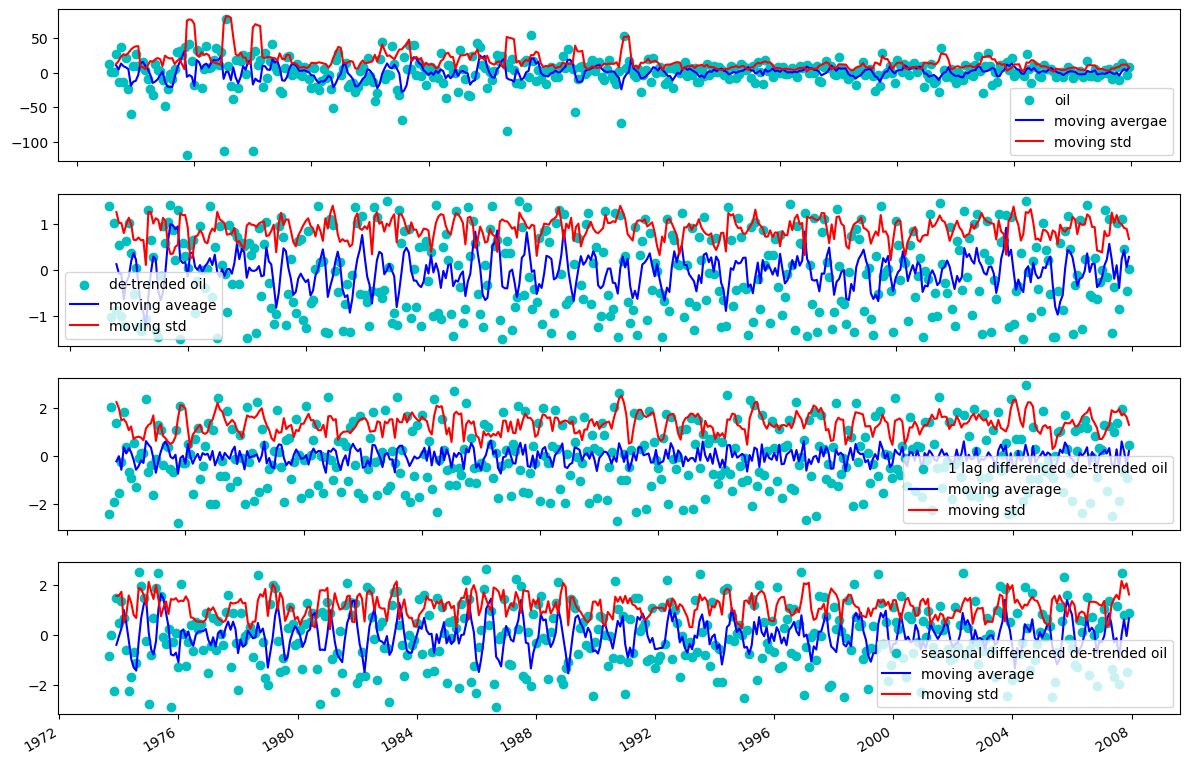

In [11]:
plot_rolling(df1,'oil')

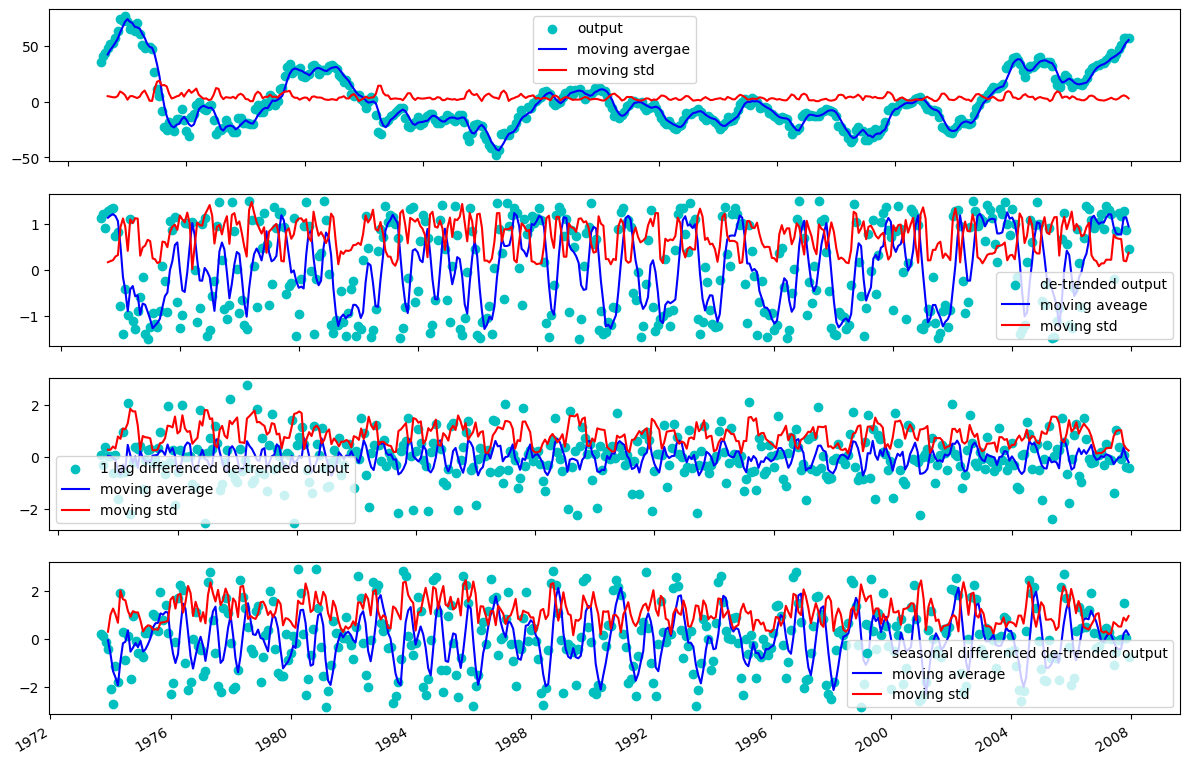

In [12]:
plot_rolling(df2,'output')

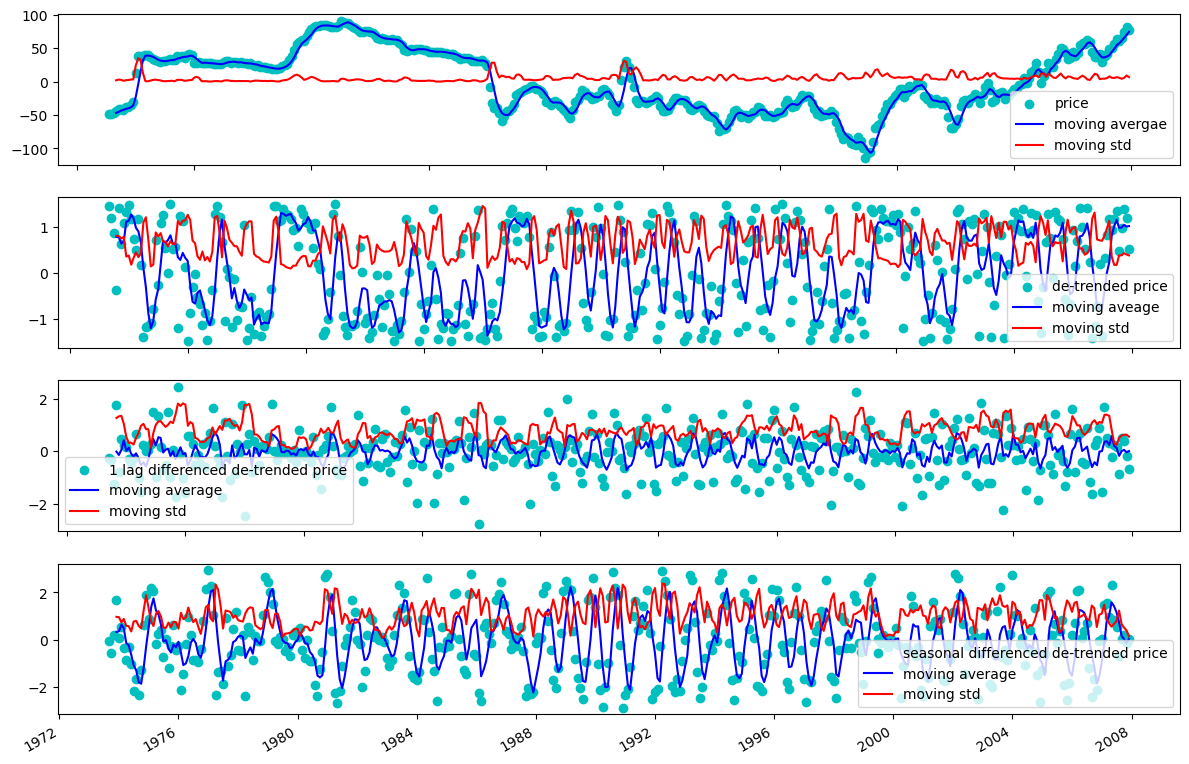

In [13]:
plot_rolling(df3,'price')

### ADF Test

In [14]:
def adf_test(df,name):
    
    print("-----------------------------------------")
    print("for variable " + name)
    print("-----------------------------------------")
    
    dftest = adfuller(df.data.dropna(), autolag='BIC')
    print("Test statistic = {:.3f}".format(dftest[0]))
    print("P-value = {:.3f}".format(dftest[1]))
    print("Critical values :")
    for k, v in dftest[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))

    print("\n > Is the de-trended data stationary ?")
    dftest = adfuller(df.z_data.dropna(), autolag='AIC')
    print("Test statistic = {:.3f}".format(dftest[0]))
    print("P-value = {:.3f}".format(dftest[1]))
    print("Critical values :")
    for k, v in dftest[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))

    print("\n > Is the 1-lag differenced de-trended data stationary ?")
    dftest = adfuller(df.zp_data.dropna(), autolag='AIC')
    print("Test statistic = {:.3f}".format(dftest[0]))
    print("P-value = {:.3f}".format(dftest[1]))
    print("Critical values :")
    for k, v in dftest[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))
    
    print("\n > Is the seasonal differenced de-trended data stationary ?")
    dftest = adfuller(df.zs_data.dropna(), autolag='AIC')
    print("Test statistic = {:.3f}".format(dftest[0]))
    print("P-value = {:.3f}".format(dftest[1]))
    print("Critical values :")
    for k, v in dftest[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))

In [15]:
adf_test(df1,'oil')

-----------------------------------------
for variable oil
-----------------------------------------
Test statistic = -22.347
P-value = 0.000
Critical values :
	1%: -3.4460914174990296 - The data is  stationary with 99% confidence
	5%: -2.868479374038333 - The data is  stationary with 95% confidence
	10%: -2.570466459559076 - The data is  stationary with 90% confidence

 > Is the de-trended data stationary ?
Test statistic = -11.883
P-value = 0.000
Critical values :
	1%: -3.4464005219454155 - The data is  stationary with 99% confidence
	5%: -2.868615280538588 - The data is  stationary with 95% confidence
	10%: -2.570538905413444 - The data is  stationary with 90% confidence

 > Is the 1-lag differenced de-trended data stationary ?
Test statistic = -10.368
P-value = 0.000
Critical values :
	1%: -3.446845912589748 - The data is  stationary with 99% confidence
	5%: -2.8688110853002007 - The data is  stationary with 95% confidence
	10%: -2.5706432834592747 - The data is  stationary with 90

In [16]:
adf_test(df2,'output')

-----------------------------------------
for variable output
-----------------------------------------
Test statistic = -2.567
P-value = 0.100
Critical values :
	1%: -3.446129402876608 - The data is not stationary with 99% confidence
	5%: -2.8684960761128346 - The data is not stationary with 95% confidence
	10%: -2.570475362616382 - The data is not stationary with 90% confidence

 > Is the de-trended data stationary ?
Test statistic = -5.960
P-value = 0.000
Critical values :
	1%: -3.4467631030732506 - The data is  stationary with 99% confidence
	5%: -2.868774682311516 - The data is  stationary with 95% confidence
	10%: -2.570623877774392 - The data is  stationary with 90% confidence

 > Is the 1-lag differenced de-trended data stationary ?
Test statistic = -7.484
P-value = 0.000
Critical values :
	1%: -3.446845912589748 - The data is  stationary with 99% confidence
	5%: -2.8688110853002007 - The data is  stationary with 95% confidence
	10%: -2.5706432834592747 - The data is  stationar

In [17]:
adf_test(df3,'price')

-----------------------------------------
for variable price
-----------------------------------------
Test statistic = -2.269
P-value = 0.182
Critical values :
	1%: -3.446129402876608 - The data is not stationary with 99% confidence
	5%: -2.8684960761128346 - The data is not stationary with 95% confidence
	10%: -2.570475362616382 - The data is not stationary with 90% confidence

 > Is the de-trended data stationary ?
Test statistic = -5.607
P-value = 0.000
Critical values :
	1%: -3.4466811208382437 - The data is  stationary with 99% confidence
	5%: -2.8687386420385494 - The data is  stationary with 95% confidence
	10%: -2.5706046655665635 - The data is  stationary with 90% confidence

 > Is the 1-lag differenced de-trended data stationary ?
Test statistic = -7.685
P-value = 0.000
Critical values :
	1%: -3.4469717056192213 - The data is  stationary with 99% confidence
	5%: -2.868866381945153 - The data is  stationary with 95% confidence
	10%: -2.570672761197837 - The data is  stationar

### We need to first diff price and output to make the series stationary

In [18]:
df['price']  = df['price'].diff(1)
df['output'] = df['output'].diff(1)

df = df.dropna()

df.head()

,oil,output,price
1973-03-01,1.42,5.46,-0.29
1973-04-01,1.18,2.46,1.20
1973-05-01,27.46,4.11,3.22
1973-06-01,-13.11,3.93,2.29
1973-07-01,36.26,0.91,0.58


In [19]:
df = df.rename(columns={"output" : "D1_output"})
df = df.rename(columns={"price"  : "D1_price"})

df.head()

,oil,D1_output,D1_price
1973-03-01,1.42,5.46,-0.29
1973-04-01,1.18,2.46,1.20
1973-05-01,27.46,4.11,3.22
1973-06-01,-13.11,3.93,2.29
1973-07-01,36.26,0.91,0.58


### Q2

From `Kilian2009old`, oil indicates the % change in global oil production and output is the measure of real economic activities. The variable price denotes the logged real crude oil price.

#### (a). 
In the last tutorial, you ordered the variables $Y_t = (oil, output, price)′$ . Estimate the responses of the oil price in responding to a structural shock on the oil supply.

In [20]:
def var_est_BIC(df,i):
    
    print("---------------------------------------------")
    print("VAR result for lag = " + str(i))
    print("---------------------------------------------")
    
    model  = VAR(df)
    result = model.fit(maxlags=i, ic='bic', trend='c',verbose=True)
    
    print(result.summary())
    
    print("---------------------------------------------")
    print("Plotting input time series")
    print("---------------------------------------------")
    
    result.plot()
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting time series autocorrelation function")
    print("---------------------------------------------")
          
    result.plot_acorr()
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting IRF")
    print("---------------------------------------------")
    
    irf = result.irf(periods = 30)
    irf.plot(orth=False, plot_stderr=True, stderr_type="mc", repl=100)
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting cumulative effects")
    print("---------------------------------------------")
    
    irf.plot_cum_effects(orth=False, plot_stderr=True, stderr_type="mc", repl=100)
    plt.show()
    
    print("---------------------------------------------")
    print("Granger test")
    print("---------------------------------------------")
    
    test_result1 = result.test_causality('oil', ['D1_output', 'D1_price'], kind='f')
    print(test_result1.summary())
    
    test_result2 = result.test_causality('D1_price', ['oil', 'D1_output'], kind='f')
    print(test_result2.summary())
    
    test_result3 = result.test_causality('D1_output', ['D1_price', 'oil'], kind='f')
    print(test_result3.summary())
    
    print("---------------------------------------------")
    print("Ljung-Box test for VAR")
    print("---------------------------------------------")
    test_result4 = result.test_whiteness()
    print(test_result4.summary())
    

---------------------------------------------
VAR result for lag = 1
---------------------------------------------
<statsmodels.tsa.vector_ar.var_model.LagOrderResults object. Selected orders are: AIC -> 1, BIC -> 1, FPE -> 1, HQIC ->  1>
Using 1 based on bic criterion
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 20, Aug, 2026
Time:                     22:09:35
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    12.9267
Nobs:                     417.000    HQIC:                   12.8565
Log likelihood:          -4434.11    FPE:                    366084.
AIC:                      12.8106    Det(Omega_mle):         355748.
--------------------------------------------------------------------
Results for equation oil
                  coefficient       std. error           t-stat            prob
------------------------------------

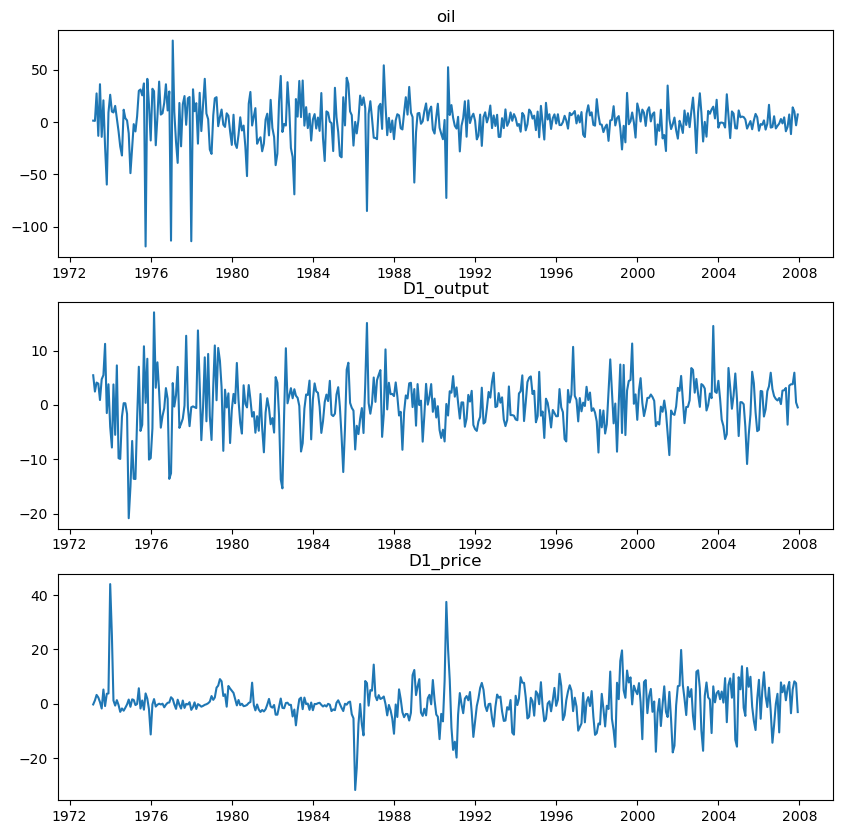

---------------------------------------------
Plotting time series autocorrelation function
---------------------------------------------


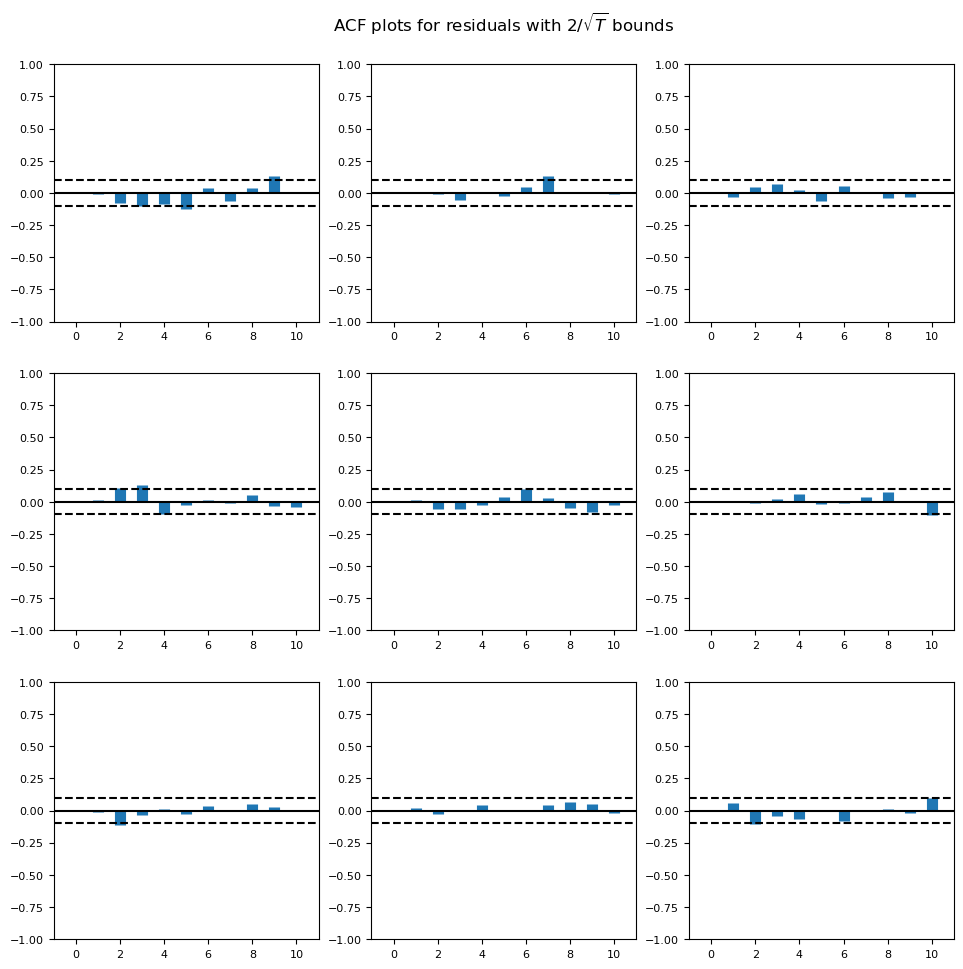

---------------------------------------------
Plotting IRF
---------------------------------------------


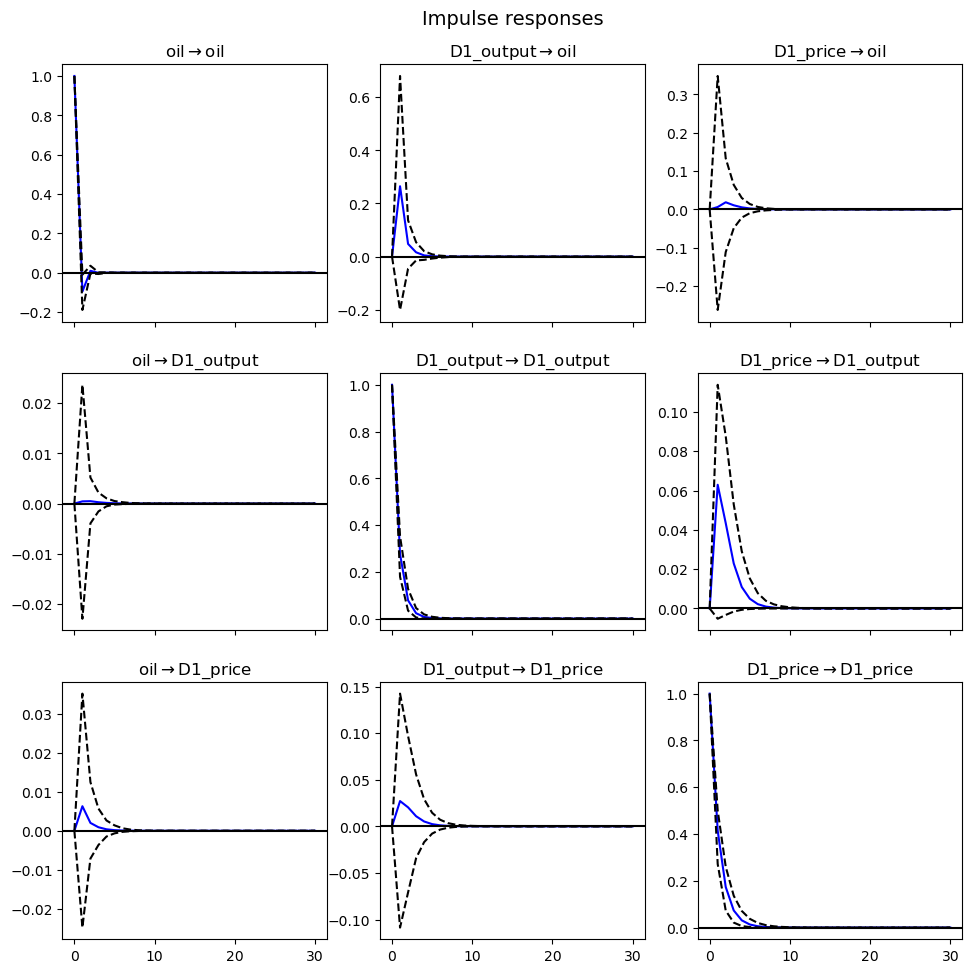

---------------------------------------------
Plotting cumulative effects
---------------------------------------------


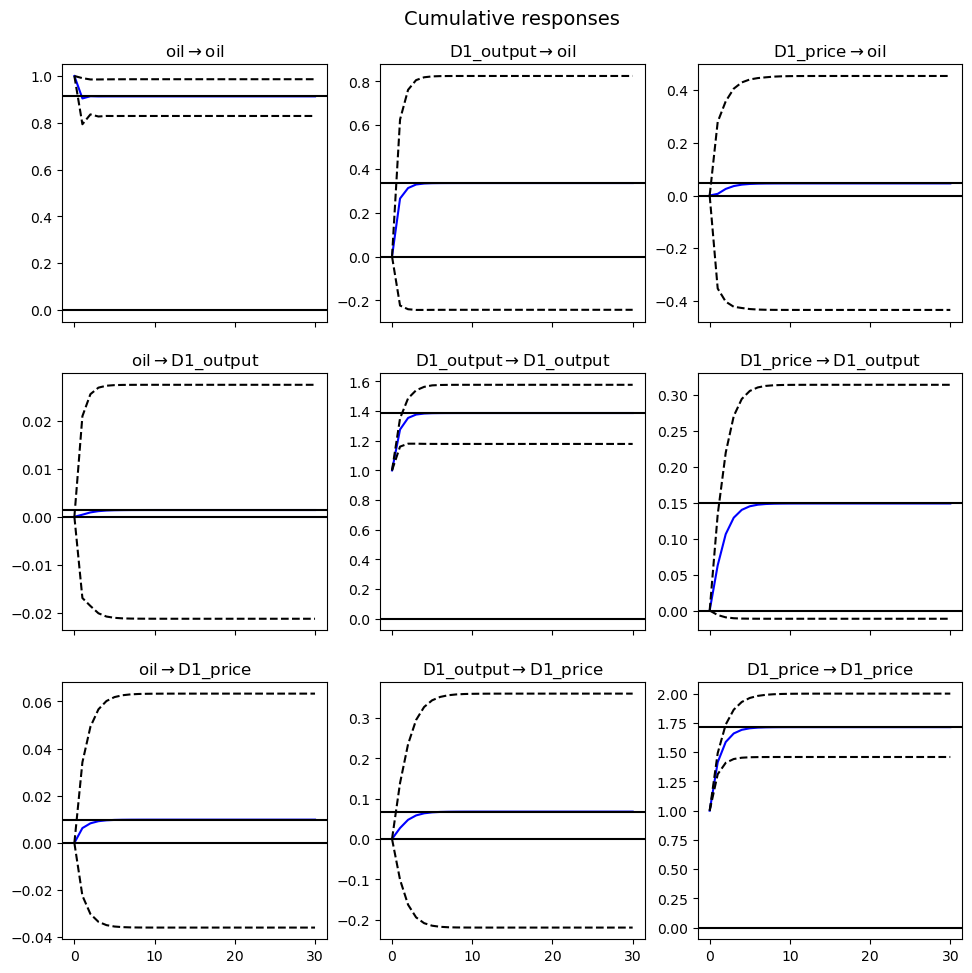

---------------------------------------------
Granger test
---------------------------------------------
Granger causality F-test. H_0: ['D1_output', 'D1_price'] do not Granger-cause oil. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.8049          3.003   0.447 (2, 1239)
-----------------------------------------------
Granger causality F-test. H_0: ['oil', 'D1_output'] do not Granger-cause D1_price. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.1896          3.003   0.827 (2, 1239)
-----------------------------------------------
Granger causality F-test. H_0: ['D1_price', 'oil'] do not Granger-cause D1_output. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-------------------------------------------

In [21]:
var_est_BIC(df,1)

#### (b).

Instead, order the variables as $Y_t = (output,oil, price)′$ and estimate the responses of the oil price in responding to a structural shock on the oil supply. Compare your estimation result from that in (a). What does it imply?

In [22]:
df.columns.tolist()

['oil', 'D1_output', 'D1_price']

###### lets change around the row order of Y vector and then reselected the model order

In [23]:
cols_new = ['D1_output', 'oil', 'D1_price']

df_new = df[cols_new]

---------------------------------------------
VAR result for lag = 1
---------------------------------------------
<statsmodels.tsa.vector_ar.var_model.LagOrderResults object. Selected orders are: AIC -> 1, BIC -> 1, FPE -> 1, HQIC ->  1>
Using 1 based on bic criterion
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 20, Aug, 2026
Time:                     22:09:38
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    12.9267
Nobs:                     417.000    HQIC:                   12.8565
Log likelihood:          -4434.11    FPE:                    366084.
AIC:                      12.8106    Det(Omega_mle):         355748.
--------------------------------------------------------------------
Results for equation D1_output
                  coefficient       std. error           t-stat            prob
------------------------------

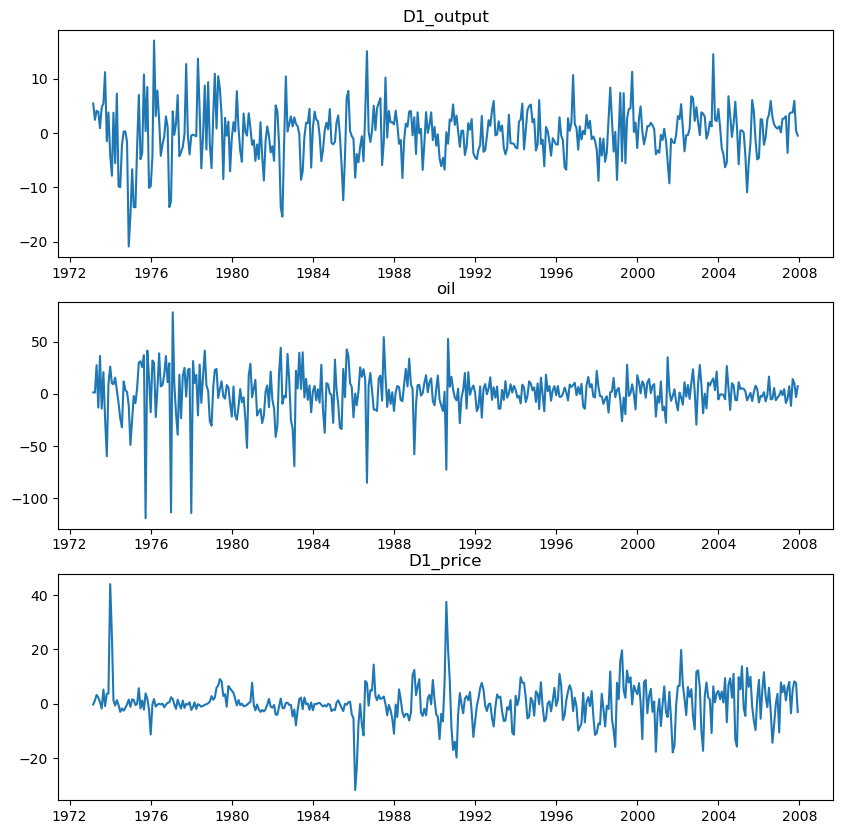

---------------------------------------------
Plotting time series autocorrelation function
---------------------------------------------


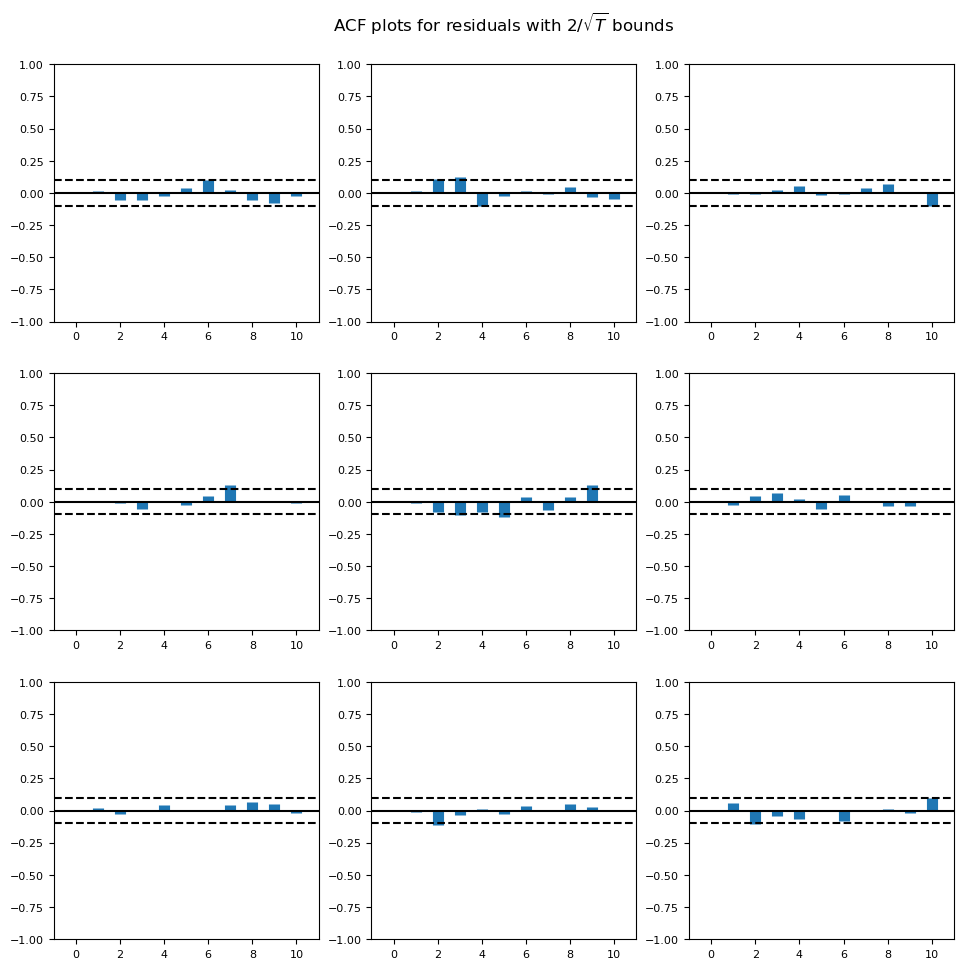

---------------------------------------------
Plotting IRF
---------------------------------------------


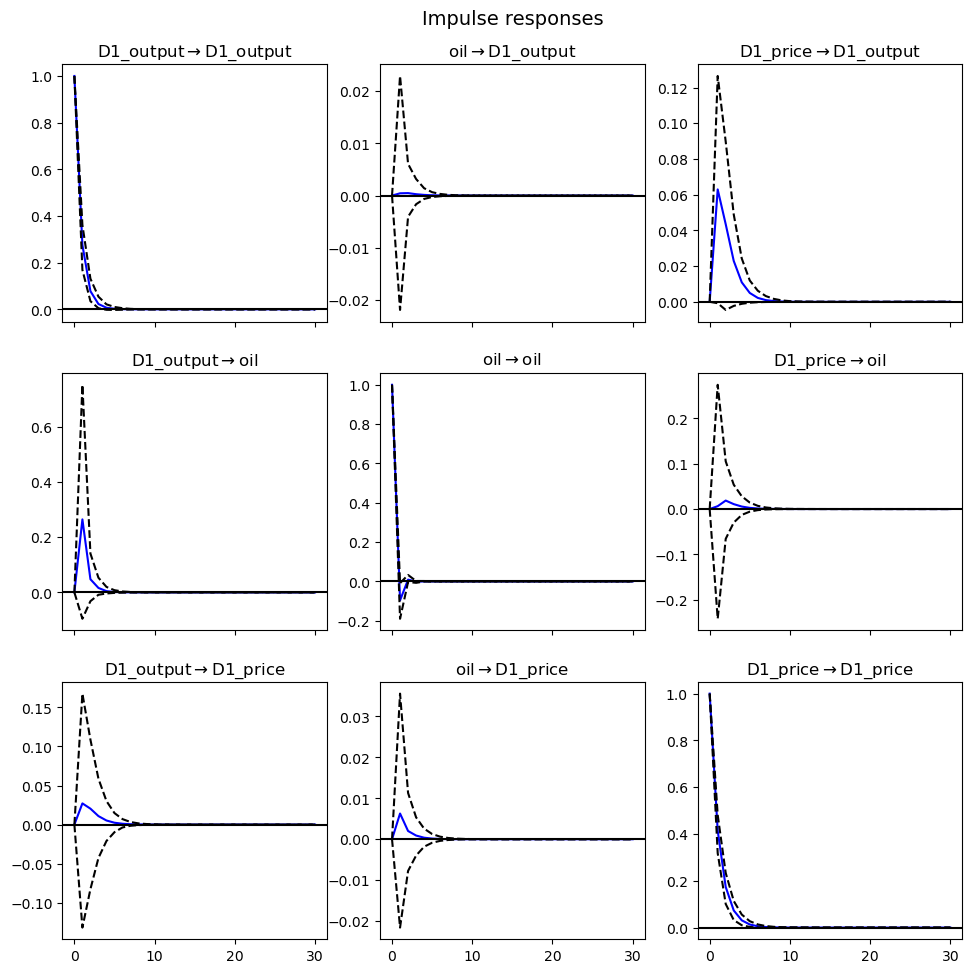

---------------------------------------------
Plotting cumulative effects
---------------------------------------------


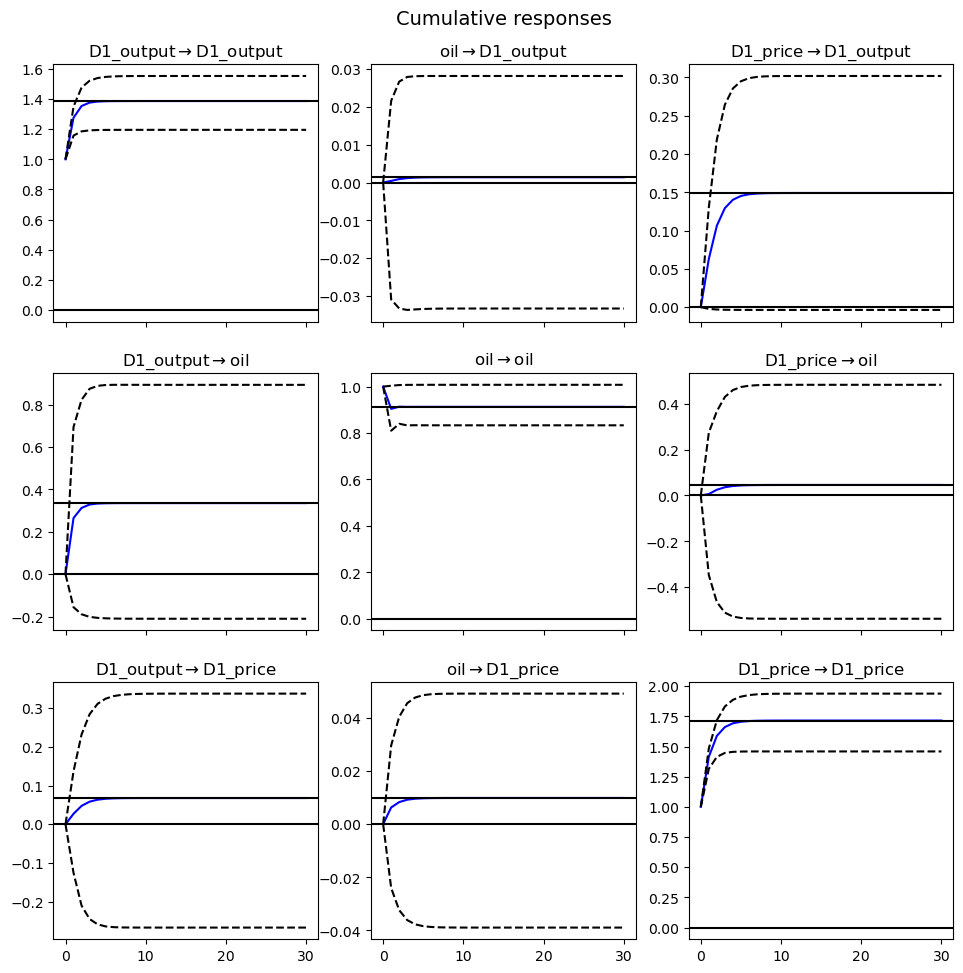

---------------------------------------------
Granger test
---------------------------------------------
Granger causality F-test. H_0: ['D1_output', 'D1_price'] do not Granger-cause oil. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.8049          3.003   0.447 (2, 1239)
-----------------------------------------------
Granger causality F-test. H_0: ['oil', 'D1_output'] do not Granger-cause D1_price. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.1896          3.003   0.827 (2, 1239)
-----------------------------------------------
Granger causality F-test. H_0: ['D1_price', 'oil'] do not Granger-cause D1_output. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-------------------------------------------

In [24]:
var_est_BIC(df_new, 1)

## Q3

`SWecmt.dta` It is quarterly data from FRED and has three variables: the growth rate of hours of worked, hwg, the growth rate of the real GDP, gdpg and the change in inflation difinf.

In [25]:
data = pd.read_stata('https://raw.githubusercontent.com/Michael-Morgan-Giles/Time_Series_Analysis/refs/heads/main/5_Structural_Vector_Autoregression/SWecmt.dta')

In [26]:
pd.date_range(start='1959-01-01', periods=236, freq='QS')

DatetimeIndex(['1959-01-01', '1959-04-01', '1959-07-01', '1959-10-01',
               '1960-01-01', '1960-04-01', '1960-07-01', '1960-10-01',
               '1961-01-01', '1961-04-01',
               ...
               '2015-07-01', '2015-10-01', '2016-01-01', '2016-04-01',
               '2016-07-01', '2016-10-01', '2017-01-01', '2017-04-01',
               '2017-07-01', '2017-10-01'],
              dtype='datetime64[ns]', length=236, freq='QS-JAN')

In [27]:
data.index = pd.date_range(start='1959-01-01', periods=236, freq='QS')

(a). Suppose that, in the long run, (i) hours of work are not affected by a shock on output or inflation and (ii) GDP is not affected by the inflation. This implies a recursive order in the variables. Obtain the optimal lag by using AIC or BIC criteria and estimate a reduced form VAR.

In [28]:
opt_lag = VAR(data[['hwg', 'gdpg', 'difinf']].dropna()).select_order(maxlags = 5).bic
print(opt_lag)

1


In [29]:
var1 =  VAR(data[['hwg', 'gdpg', 'difinf']].dropna()).fit(maxlags=opt_lag, trend='c',verbose=True)
    
print(var1.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 20, Aug, 2026
Time:                     22:09:42
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -24.0488
Nobs:                     233.000    HQIC:                  -24.1549
Log likelihood:           1842.55    FPE:                3.00987e-11
AIC:                     -24.2265    Det(Omega_mle):     2.86003e-11
--------------------------------------------------------------------
Results for equation hwg
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.000501         0.000557            0.900           0.368
L1.hwg            0.530294         0.069976            7.578           0.000
L1.gdpg           0.140101         0.066370            2.111           0.035
L

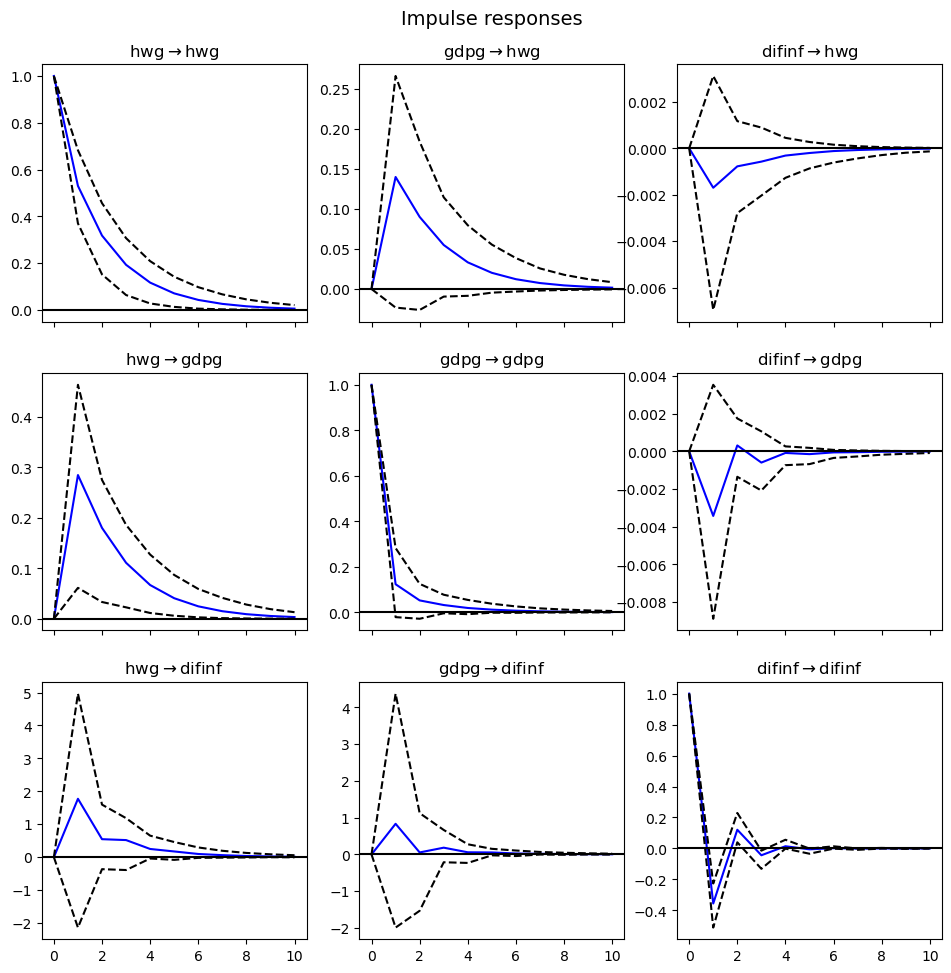

In [30]:
var1.irf(periods=10).plot(plot_stderr=True, stderr_type="mc", repl=100)
plt.show()

(b). Impose a long run restriction in (a) and estimate the structural impulse response IRF(h) for $h = 1, . . . , 10$. Visualize the estimated impulse responses with their confidence band. Interpret your finding.

`statsmodel` doesn't appear to have a direct way to apply long-run restrictions. So instead, i'm going to just run a typical $AB$, $A$ and $B$ Structural Vector Autoregression for the lols. The `R` script has an example of a long-run restriction.

We can look at how the impluse response functions change for each approach.

## AB Model

In [31]:
A_mat = np.asarray([['1', '0', '0'],  
                    ['0', '1', '0'], 
                    ['0', '0', '1'] ])

B_mat = np.asarray([['E', '0', '0'],  
                    ['E', 'E', '0'], 
                    ['E', 'E', 'E']])

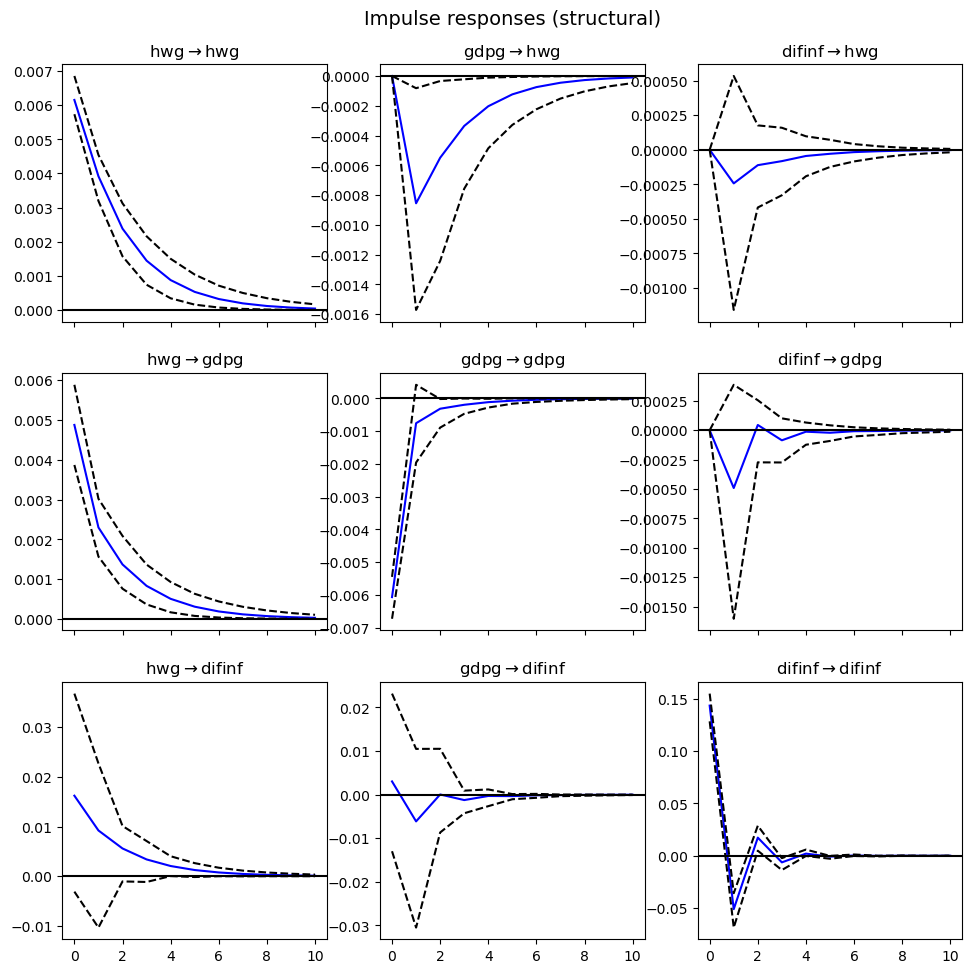

In [32]:
import warnings
warnings.filterwarnings("ignore")
svar_AB_res = SVAR(data[['hwg', 'gdpg', 'difinf']].dropna(), 
               svar_type="AB", 
               A=A_mat, 
               B=B_mat).fit(maxlags=opt_lag, maxiter=10000, maxfun=10000, solver="bfgs")
svar_AB_res.irf(periods=10).plot(plot_stderr=True,
                         stderr_type="mc", repl=100)
plt.show()

In [33]:
# issues in statsmodel means you have to set this to zero, coefficients look the same
svar_AB_res.k_exog_user = 0
print(svar_AB_res.summary())

  Summary of Regression Results   
Model:                        SVAR
Method:                        OLS
Date:           Thu, 20, Aug, 2026
Time:                     22:09:47
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -24.0488
Nobs:                     233.000    HQIC:                  -24.1549
Log likelihood:           1842.55    FPE:                3.00987e-11
AIC:                     -24.2265    Det(Omega_mle):     2.86003e-11
--------------------------------------------------------------------
Results for equation hwg
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.000501         0.000557            0.900           0.368
L1.hwg            0.530294         0.069976            7.578           0.000
L1.gdpg           0.140101         0.066370            2.111           0.035
L

(c). Estimate the forecast error decomposition due to a change in outputs. Interpret your
finding.

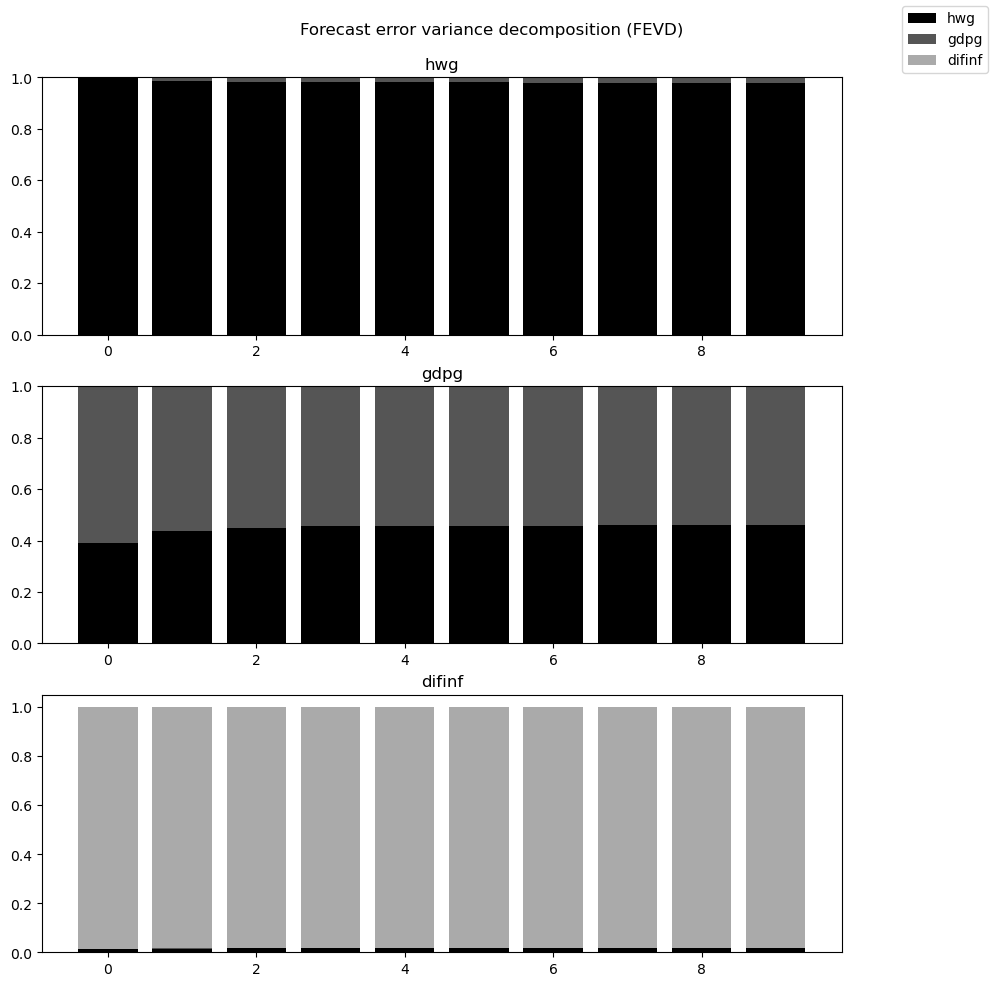

In [34]:
var1.fevd(periods = 10).plot()
plt.show()

## A Model

In [35]:
A_mat = np.asarray([['1', '0', '0'],  
                    ['E', '1', '0'], 
                    ['E', 'E', '1'] ])

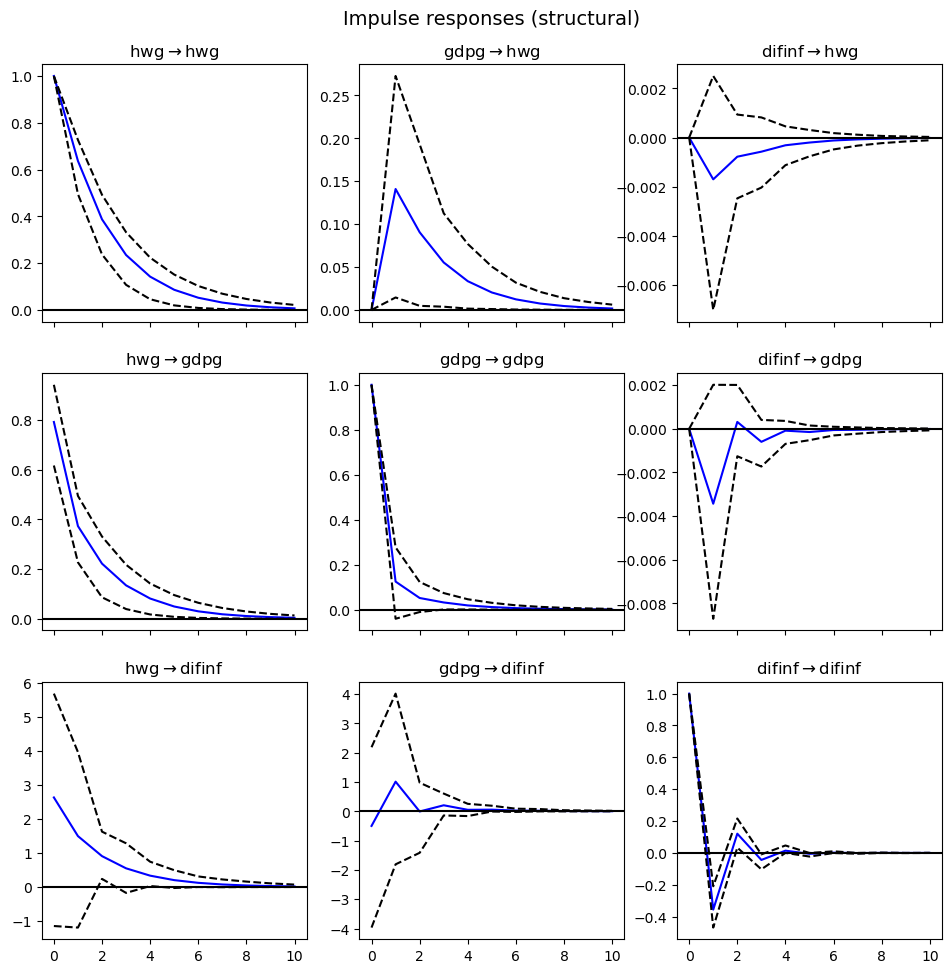

In [36]:
import warnings
warnings.filterwarnings("ignore")
svar_A_res = SVAR(data[['hwg', 'gdpg', 'difinf']].dropna(), 
               svar_type="A", 
               A=A_mat).fit(maxlags=opt_lag, maxiter=10000, maxfun=10000, solver="bfgs")
svar_A_res.irf(periods=10).plot(plot_stderr=True,
                         stderr_type="mc", repl=100)
plt.show()

## B Model

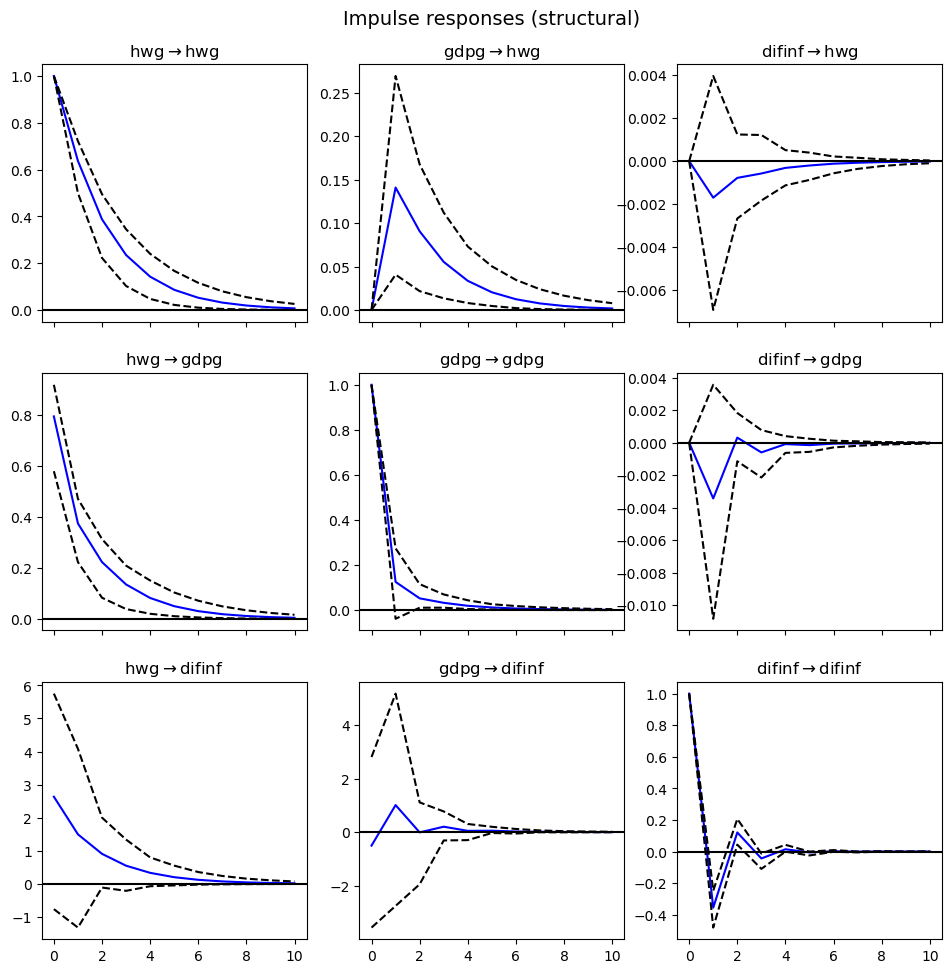

In [37]:
B_mat = np.asarray([['1', '0', '0'],  
                    ['E', '1', '0'], 
                    ['E', 'E', '1']])

import warnings
warnings.filterwarnings("ignore")
svar_B_res = SVAR(data[['hwg', 'gdpg', 'difinf']].dropna(), 
               svar_type="B",
                 B = B_mat).fit(maxlags=opt_lag, maxiter=10000, maxfun=10000, solver="bfgs")
svar_B_res.irf(periods=10).plot(plot_stderr=True,
                         stderr_type="mc", repl=100)
plt.show()